Data Processing Notebook
===

Prepare the downloaded dataset, stored as `.root` files in the data_loader step, for NSBI analysis by performing preselections and remove ill-modeled and low-stats phase space regions. 

The root ntuples will loaded into `pandas.DataFrame` for preprocessing and then saved for NSBI density ratio trainings and inference.

#### Note: you can choose not to run the data processing steps if you preform a `git lfs pull` to download the pre-saved and pre-processed datasets.

In [1]:
import os, sys, importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mplhep as hep
import yaml
import uproot

import nsbi_common_utils
from nsbi_common_utils import configuration
from nsbi_common_utils import datasets


import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

hep.style.use(hep.style.ATLAS)

In [2]:
def load_config(path: str) -> dict:
    with open(path, "r") as f:
        return yaml.safe_load(f)

In [3]:
data_processing_config = load_config("config.pipeline.yaml")["data_preprocessing"]

Define branches to load
==

Classified in terms of the number of jets for feature engineering later.

In [4]:
features = data_processing_config["features"]

print(f"Features to use for downstream training: \n\n {features}")

Features to use for downstream training: 

 ['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta', 'PRI_had_phi', 'PRI_met', 'PRI_met_phi', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_had', 'DER_met_phi_centrality', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_all_pt', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_lep_eta_centrality', 'PRI_n_jets']


In [6]:
# load the corresponding branches from ntuple
branches_to_load = features
print(branches_to_load)

['PRI_lep_pt', 'PRI_lep_eta', 'PRI_lep_phi', 'PRI_had_pt', 'PRI_had_eta', 'PRI_had_phi', 'PRI_met', 'PRI_met_phi', 'DER_mass_transverse_met_lep', 'DER_mass_vis', 'DER_pt_h', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt', 'DER_pt_ratio_lep_had', 'DER_met_phi_centrality', 'PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_all_pt', 'PRI_jet_subleading_pt', 'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 'DER_prodeta_jet_jet', 'DER_lep_eta_centrality', 'PRI_n_jets']


Loading the datasets_helper
---

The `nsbi_common_utils.datasets` library provides a class `datasets`, which is a lightweight helper class for the various utilities related to reading, processing and saving datasets.

In [8]:
datasets_helper = nsbi_common_utils.datasets.datasets(
                                                        config_path = data_processing_config['fit_config_path'],
                                                        branches_to_load = branches_to_load
                                                    )
datasets_all = datasets_helper.load_datasets_from_config(load_systematics = True)


Preprocessing
--

Here we perform some simple feature engineering, particularly focusing on jet variables whose impact on the final likelihood is permutation invariant.

Kinetmatic features with long tails are also transformed using `log` functions to help the neural network trainings.

In [5]:
# Classify all the input features in this dataset in terms of their jet multiplicity
# This is purely for feature engineering choices done later
input_features_1Jets = ['PRI_jet_leading_pt', 'PRI_jet_leading_eta',
    'PRI_jet_leading_phi',
    'PRI_jet_all_pt']

input_features_2Jets = ['PRI_jet_subleading_pt',
    'PRI_jet_subleading_eta', 'PRI_jet_subleading_phi', 'DER_deltaeta_jet_jet', 'DER_mass_jet_jet',
    'DER_prodeta_jet_jet',
    'DER_lep_eta_centrality']

input_features_nJets = ['PRI_n_jets']

# Remove the features that are not defined for use in the configuration file
for feat in input_features_1Jets:
    if feat not in features:
        input_features_1Jets.remove(feat)

for feat in input_features_2Jets:
    if feat not in features:
        input_features_2Jets.remove(feat)

for feat in input_features_nJets:
    if feat not in features:
        input_features_nJets.remove(feat)

In [7]:
input_features_by_jet = {
    1: input_features_1Jets, 
    2: input_features_2Jets
}

In [11]:
def process_data(df: dict, input_features_by_jet: dict, branches: list) -> tuple:
    """
    Apply feature engineering to all samples in all regions.
    
    Returns:
        (modified_df_dict, list_of_new_branch_names)
    """
    median_feature = {}

    # Calculate medians from nominal samples
    nominal_data = df["Nominal"]

    for sample, sample_dataset in nominal_data.items(): 
        median_feature[sample] = {}
        for n_jets, feat_list in input_features_by_jet.items():
            for feature in feat_list:
                # Calculate median for events with n_jets >= threshold
                vals = sample_dataset.loc[sample_dataset['PRI_n_jets'] >= n_jets, feature]
                median_feature[sample][feature] = np.median(vals)

    branches_to_add = []

    # Apply engineering to all datasets (systematics/regions)
    for region, sample_datasets in df.items():
        for sample, sample_dataset in sample_datasets.items():
            
            df_modified = sample_dataset.copy()
            
            # --- Categorical jet masks ---
            df_modified['njet_0'] = (df_modified['PRI_n_jets'] == 0).astype(int)
            df_modified['njet_1'] = (df_modified['PRI_n_jets'] == 1).astype(int)
            df_modified['njet_2'] = (df_modified['PRI_n_jets'] >= 2).astype(int)

            for mask_name in ['njet_0', 'njet_1', 'njet_2']:
                if mask_name not in branches_to_add:
                    branches_to_add.append(mask_name)

            # --- Jet feature processing ---
            for n_jets, feat_list in input_features_by_jet.items():
                mask_col = f'jet{n_jets}_mask'
                df_modified[mask_col] = (df_modified['PRI_n_jets'] >= n_jets).astype(float)
                
                if mask_col not in branches_to_add:
                    branches_to_add.append(mask_col)

                for feat in feat_list:
                    df_modified[feat] = df_modified[feat].where(df_modified['PRI_n_jets'] >= n_jets, 
                                                                median_feature[sample][feat])
                    

            # --- Log transformations when distributions spread out ---
            for feat in branches:
                if feat not in df_modified.columns:
                    continue

                kin = df_modified[feat].to_numpy()

                # Only apply log if all values are positive and range is large
                if (np.amin(kin) > 0.0) and (np.amax(kin) > 100.0):
                    log_feat = f'log_{feat}'
                    df_modified[log_feat] = np.log(kin + 10.0)
                    
                    if log_feat not in branches_to_add:
                        branches_to_add.append(log_feat)

            df[region][sample] = df_modified.copy()

    return df, branches_to_add


In [12]:
datasets_all, new_branches = process_data(
            datasets_all, 
            input_features_by_jet, 
            branches=branches_to_load
        )

Computing medians from Nominal samples for imputation...
Applying feature engineering to all regions and samples...


Append the additional branches from engineered features back into the dataset and save back to the original `.root` ntuples defined in the data_processing_config file.

In [13]:
datasets_helper.add_appended_branches(new_branches)
datasets_helper.save_dataset_to_ntuple(datasets_all, save_systematics=True)

Saved 3 tree(s) to saved_datasets/dataset_nominal.root: ['tree_htautau', 'tree_ttbar', 'tree_ztautau']
Saved 3 tree(s) to saved_datasets/dataset_JES_up.root: ['tree_htautau', 'tree_ztautau', 'tree_ttbar']
Saved 3 tree(s) to saved_datasets/dataset_JES_dn.root: ['tree_htautau', 'tree_ztautau', 'tree_ttbar']
Saved 3 tree(s) to saved_datasets/dataset_TES_up.root: ['tree_htautau', 'tree_ztautau', 'tree_ttbar']
Saved 3 tree(s) to saved_datasets/dataset_TES_dn.root: ['tree_htautau', 'tree_ztautau', 'tree_ttbar']


Visualize the data
-

Check for low-stats phase space and effect from systematics before moving to the density ratio training.

NSBI workflows need precise estimate of the density ratios as a function of the full kinematic phase space. If regions exist with low-stats they can be filtered out by passing query strings to the `Filter` section of the `Regions` entries. E.g.:

```
Regions:
-   Name: CR
    Filter: kin_feature_xyz<=100.0
```

In [14]:
def plot_kinematic_features(
    columns,
    nbins,
    variations_to_plot,
    dataset_dict,
    xlabel_dict,
    samples_list
):
    """
    For each feature in `columns`, builds weighted histograms for each (label, variation)
    and then plots them on a grid of subplots.

    Parameters
    ----------
    columns : list of str
        List of dataframe‐column names to histogram.
    nbins : int
        Number of bins to use (based on the 'nominal' variation of each feature).
    variations_to_plot : list of str
        Keys in `dataset_dict` (e.g. ['nominal','TES_up','TES_dn']).
    dataset_dict : dict[str -> pandas.DataFrame]
        Mapping each variation name to a DataFrame.  Each DataFrame must have columns:
            - feature columns in `columns`
            - "detailed_labels" (to mask by label)
            - "weights"
    xlabel_dict : dict[str->str]
        Mapping each feature name → label for the x‐axis.
    samples_list : list
        The list of sample labels to loop over.

    Returns
    -------
    fig, axes
        The Figure and array of Axes where the histograms were drawn.
    """
    # Compute all histograms and bins
    hist = {feat: {lbl: {} for lbl in samples_list} for feat in columns}
    bins_dict = {}

    for feature in columns:
        for label in samples_list:
            # Compute bins from the 'nominal' dataset
            arr_nom = dataset_dict['Nominal'][label][feature].to_numpy()
            bins = np.histogram_bin_edges(arr_nom, bins=nbins)
            bins_dict[feature] = bins
            break

        # For each variation & label, fill the histogram
        for variation in variations_to_plot:
            for label in samples_list:
                df_var = dataset_dict[variation][label]
                vals = df_var[feature].to_numpy()
                wts = df_var["weights"].to_numpy()
                hist_vals, _ = np.histogram(vals, weights=wts, bins=bins)
                hist[feature][label][variation] = hist_vals

    # Set up a grid of subplots (up to 2 columns, adjusting rows if needed)
    n_plots = len(columns)
    ncols = 2
    nrows = int(np.ceil(n_plots / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 5 * nrows))
    axes = axes.flatten()

    # Prepare color/linestyle maps
    palette = plt.rcParams['axes.prop_cycle'].by_key()['color']
    color_label_map = {lbl: palette[i % len(palette)] for i, lbl in enumerate(samples_list)}
    linestyle_map = {
        variations_to_plot[0]: '-',
        variations_to_plot[1]: '--',
        variations_to_plot[2]: '--'
    }

    # Plot each feature in its own Axes
    for ax, feature in zip(axes, columns):
        for label in samples_list:
            for variation in variations_to_plot:
                hep.histplot(
                    hist[feature][label][variation],
                    bins=bins_dict[feature],
                    label=(label if variation == 'Nominal' else None),
                    ax=ax,
                    linewidth=1.5,
                    color=color_label_map[label],
                    linestyle=linestyle_map.get(variation, '-')
                )

        ax.set_yscale('log')
        ax.set_xlabel(xlabel_dict.get(feature, feature), size=14)
        ax.set_ylabel('Events', size=14)
        ax.legend()

    # If there are unused subplots (e.g. 3 features → 4 subplots), turn off extras
    for i in range(n_plots, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    return fig, axes

In [15]:
samples_list = list(datasets_all["Nominal"].keys())

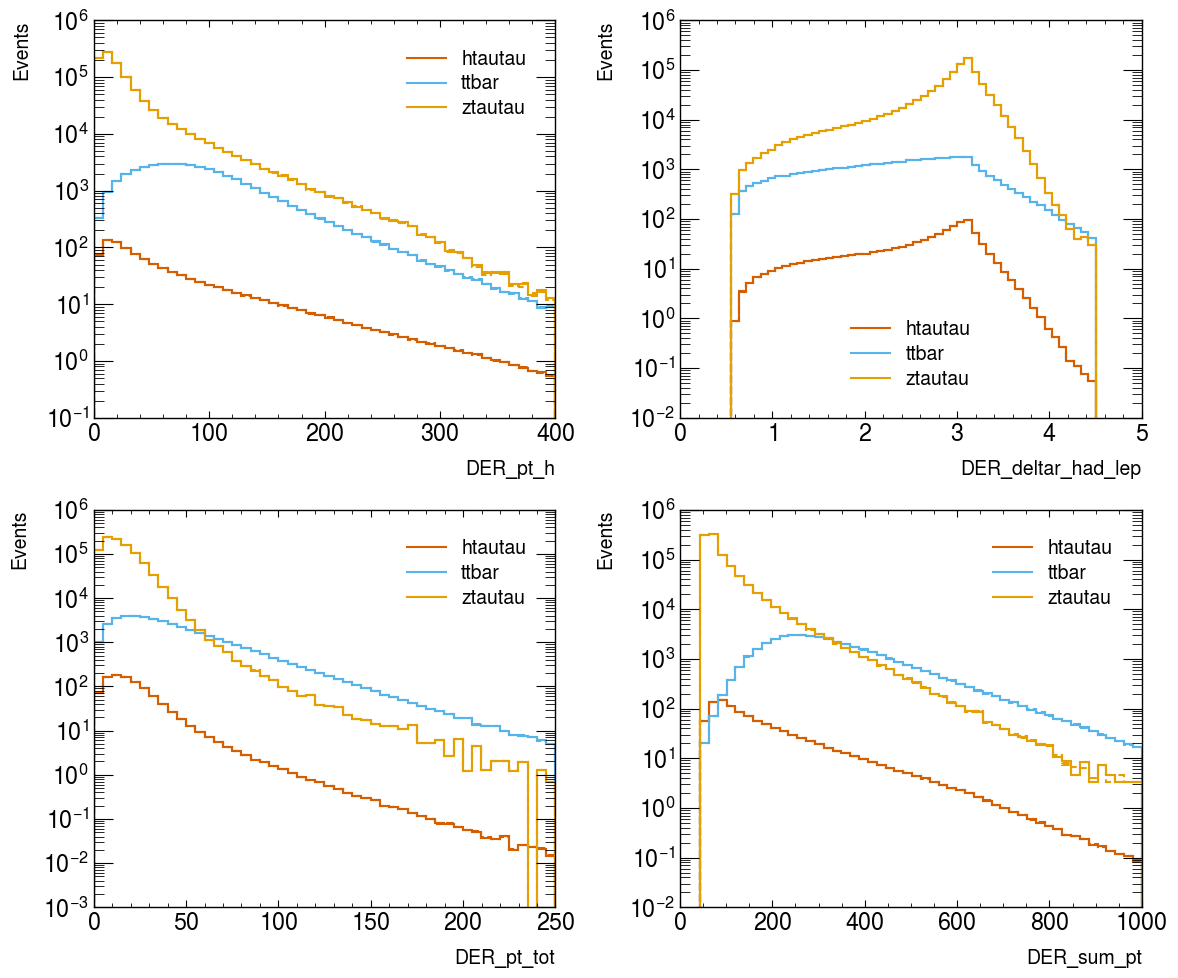

In [16]:
columns = ['DER_pt_h', 'DER_deltar_had_lep', 'DER_pt_tot', 'DER_sum_pt']
nbins = 50

xlabel_dict = {
    'PRI_lep_pt': 'lepton $p_T$ [GeV]', 
    'PRI_lep_eta': 'lepton $\\eta$ [GeV]', 
    'PRI_met': 'MET [GeV]', 
    'PRI_met_phi': 'MET $\\phi$',     
    'PRI_n_jets': '$n_{jets}$'      
}

variations_to_plot = ['Nominal', 'JES_Up', 'JES_Dn']

fig, axes = plot_kinematic_features(
    columns=columns,
    nbins=nbins,
    variations_to_plot=variations_to_plot,
    dataset_dict=datasets_all,
    xlabel_dict=xlabel_dict,
    samples_list=samples_list
)
plt.show()


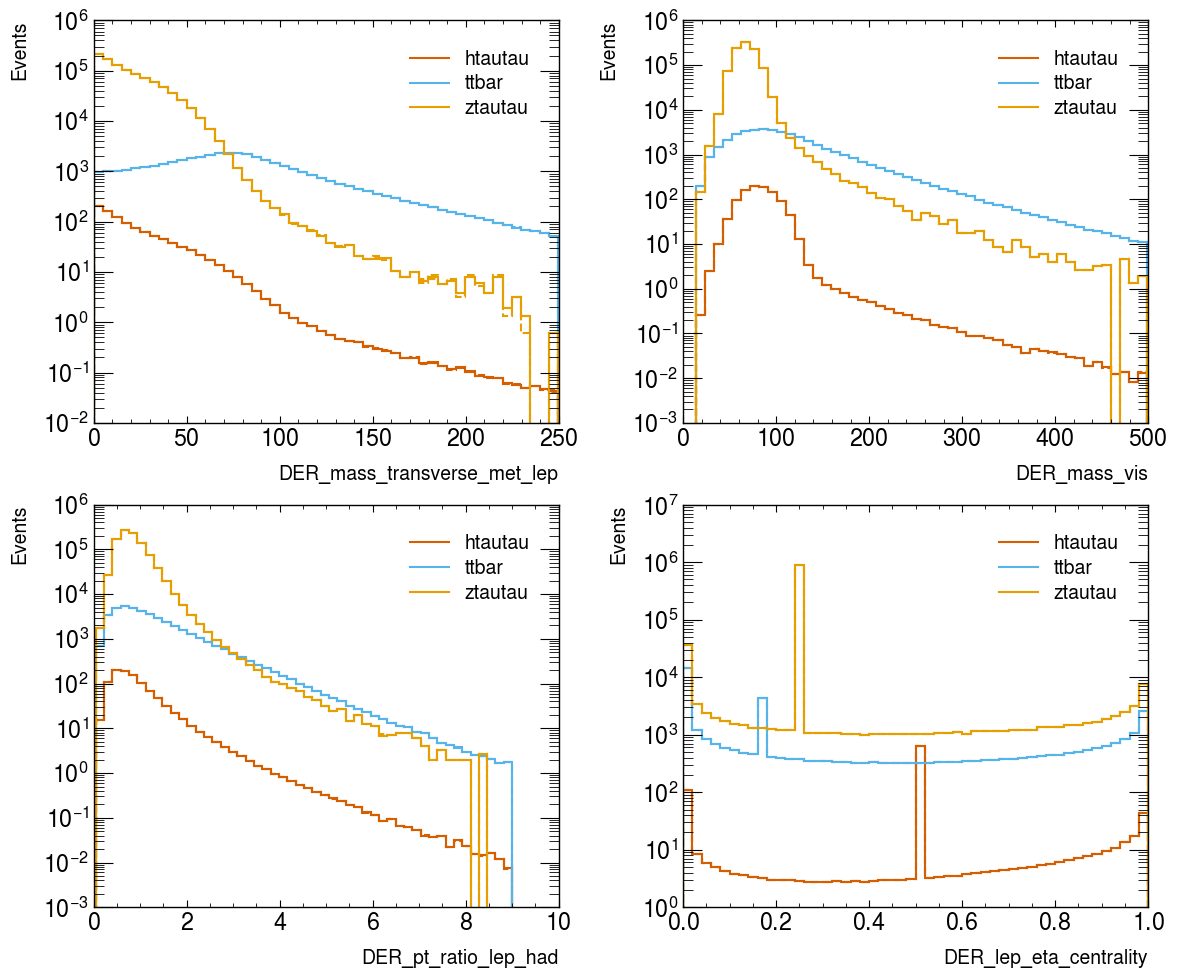

In [17]:
columns = ['DER_mass_transverse_met_lep', 'DER_mass_vis',
       'DER_pt_ratio_lep_had', 'DER_lep_eta_centrality']

nbins = 50

xlabel_dict = {
    'DER_mass_transverse_met_lep': 'DER_mass_transverse_met_lep', 
    'DER_mass_vis': 'DER_mass_vis', 
    'DER_pt_ratio_lep_had': 'DER_pt_ratio_lep_had', 
    'DER_lep_eta_centrality': 'DER_lep_eta_centrality',       
}

variations_to_plot = ['Nominal', 'JES_Up', 'JES_Dn']


fig, axes = plot_kinematic_features(
    columns=columns,
    nbins=nbins,
    variations_to_plot=variations_to_plot,
    dataset_dict=datasets_all,
    xlabel_dict=xlabel_dict,
    samples_list=samples_list
)
plt.show()



<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_101450/2432422146.py:8: SyntaxWarning: invalid escape sequence '\e'
  'DER_prodeta_jet_jet': '$\eta_{j1}\eta_{j2}$',


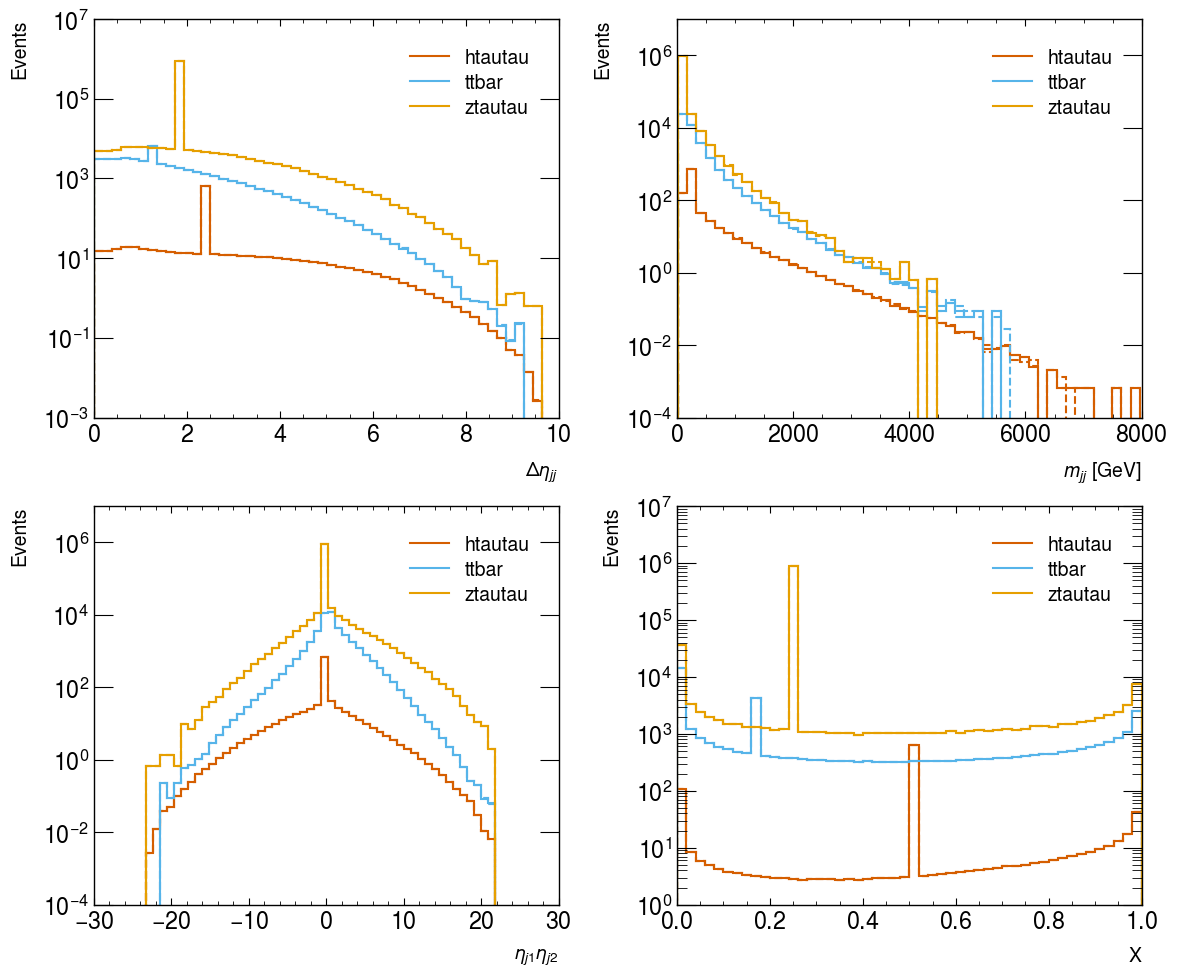

In [18]:
columns = ['DER_deltaeta_jet_jet', 'DER_mass_jet_jet', 
           'DER_prodeta_jet_jet', 'DER_lep_eta_centrality']
nbins = 50

xlabel_dict = {
    'DER_deltaeta_jet_jet': r'$\Delta \eta_{jj}$', 
    'DER_mass_jet_jet': '$m_{jj}$ [GeV]', 
    'DER_prodeta_jet_jet': '$\eta_{j1}\eta_{j2}$', 
    'DER_lep_eta_centrality': 'X',
}

variations_to_plot = ['Nominal', 'JES_Up', 'JES_Dn']


fig, axes = plot_kinematic_features(
    columns=columns,
    nbins=nbins,
    variations_to_plot=variations_to_plot,
    dataset_dict=datasets_all,
    xlabel_dict=xlabel_dict,
    samples_list=samples_list
)
plt.show()

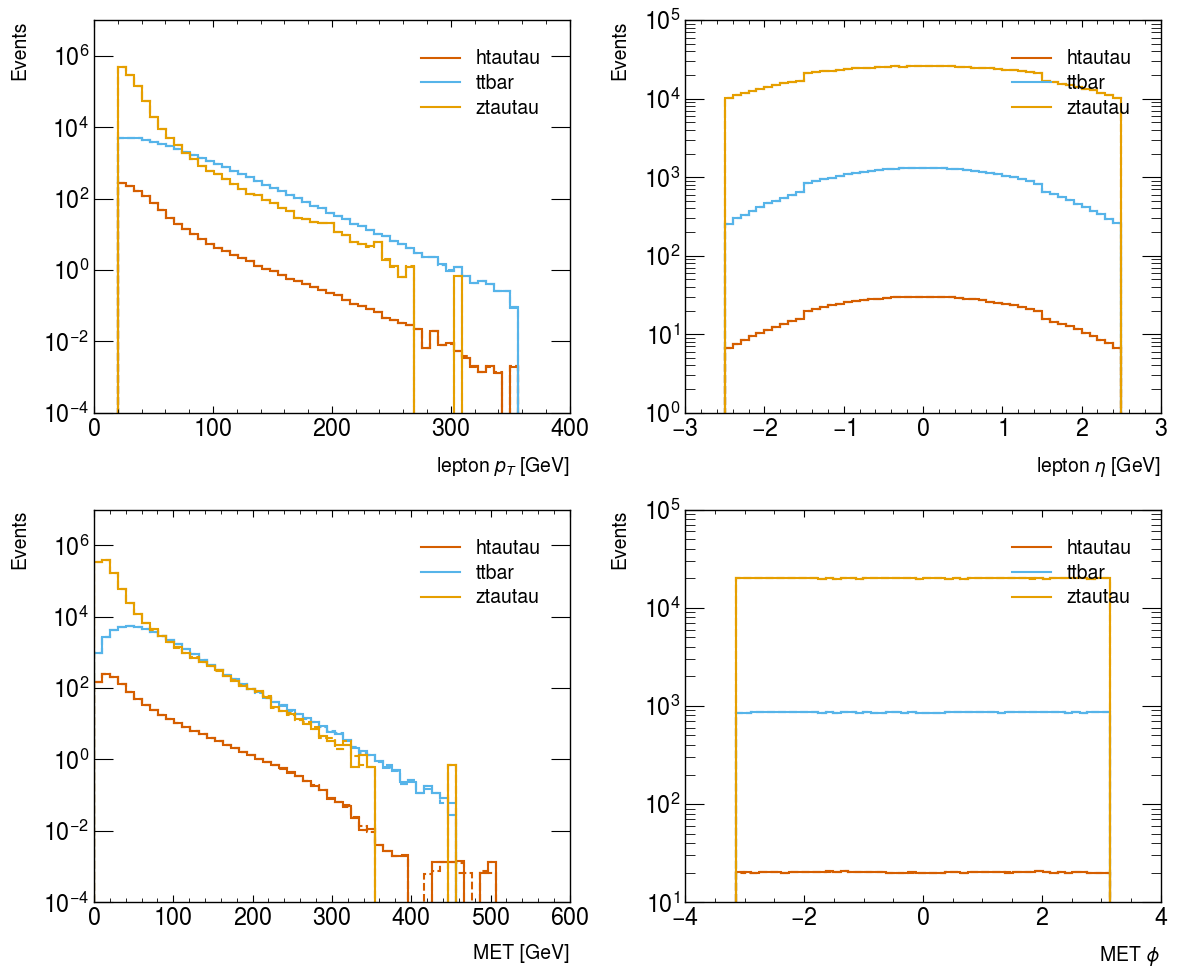

In [19]:
columns = ['PRI_lep_pt', 'PRI_lep_eta', 'PRI_met', 'PRI_met_phi']
nbins = 50

xlabel_dict = {
    'PRI_lep_pt': 'lepton $p_T$ [GeV]', 
    'PRI_lep_eta': 'lepton $\\eta$ [GeV]', 
    'PRI_met': 'MET [GeV]', 
    'PRI_met_phi': 'MET $\\phi$',     
    'PRI_n_jets': '$n_{jets}$'      
}

variations_to_plot = ['Nominal', 'JES_Up', 'JES_Dn']


fig, axes = plot_kinematic_features(
    columns=columns,
    nbins=nbins,
    variations_to_plot=variations_to_plot,
    dataset_dict=datasets_all,
    xlabel_dict=xlabel_dict,
    samples_list=samples_list
)
plt.show()


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\p'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:8: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_101450/3719328280.py:7: SyntaxWarning: invalid escape sequence '\e'
  'PRI_had_eta': 'hadron $\eta$ [GeV]',
/tmp/ipykernel_101450/3719328280.py:8: SyntaxWarning: invalid escape sequence '\p'
  'PRI_had_phi': 'hadron $\phi$',


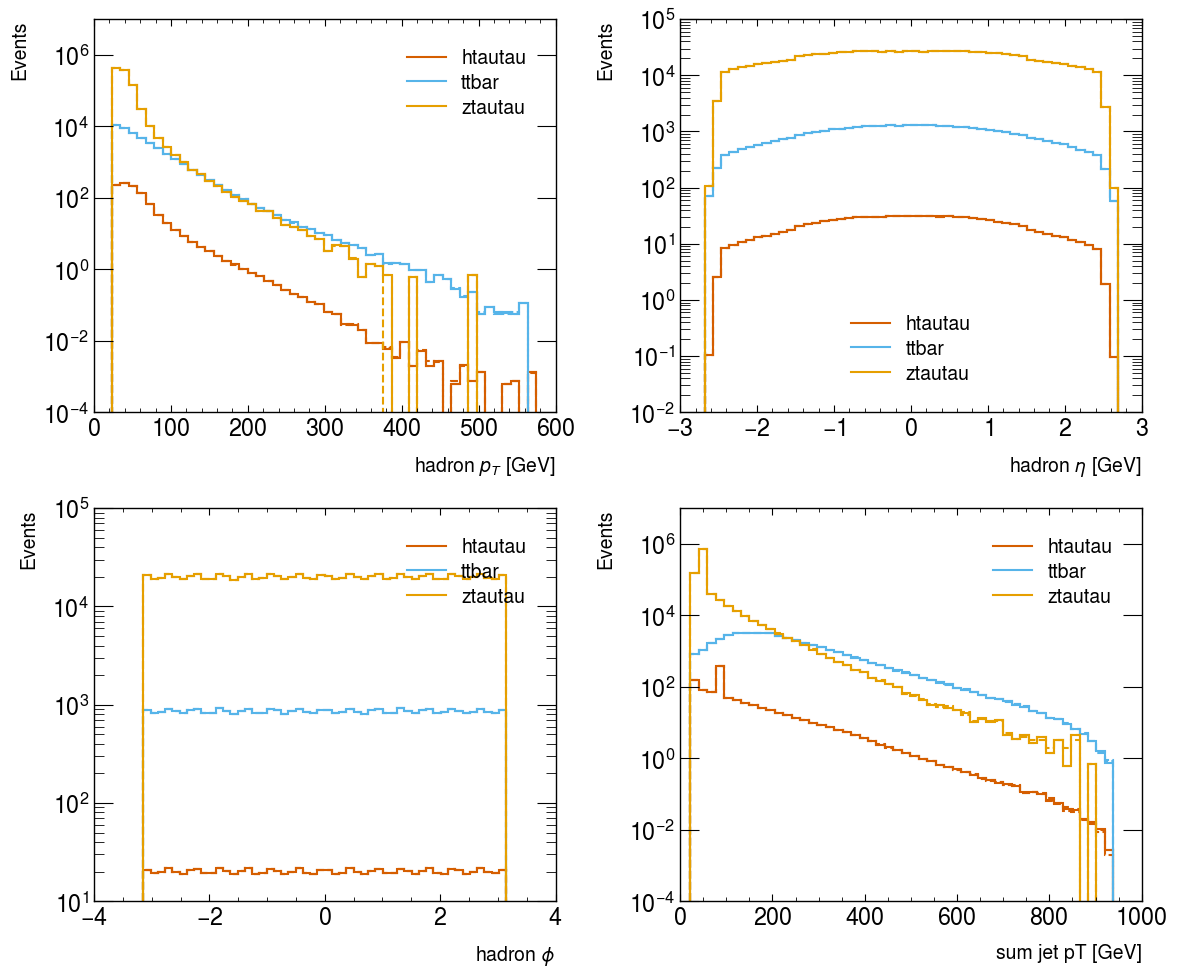

In [20]:
columns = ['PRI_had_pt', 'PRI_had_eta', 'PRI_had_phi', 'PRI_jet_all_pt']
# columns = ['PRI_had_pt', 'PRI_had_eta', 'PRI_had_phi']
nbins = 50

xlabel_dict = {
    'PRI_had_pt': 'hadron $p_T$ [GeV]', 
    'PRI_had_eta': 'hadron $\eta$ [GeV]', 
    'PRI_had_phi': 'hadron $\phi$', 
    'PRI_jet_all_pt': 'sum jet pT [GeV]',
}

variations_to_plot = ['Nominal', 'JES_Up', 'JES_Dn']


fig, axes = plot_kinematic_features(
    columns=columns,
    nbins=nbins,
    variations_to_plot=variations_to_plot,
    dataset_dict=datasets_all,
    xlabel_dict=xlabel_dict,
    samples_list=samples_list
)
plt.show()

<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\p'
<>:8: SyntaxWarning: invalid escape sequence '\e'
<>:9: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_101450/2362404005.py:8: SyntaxWarning: invalid escape sequence '\e'
  'PRI_jet_leading_eta': 'leading jet $\eta$ [GeV]',
/tmp/ipykernel_101450/2362404005.py:9: SyntaxWarning: invalid escape sequence '\p'
  'PRI_jet_leading_phi': 'leading jet $\phi$',


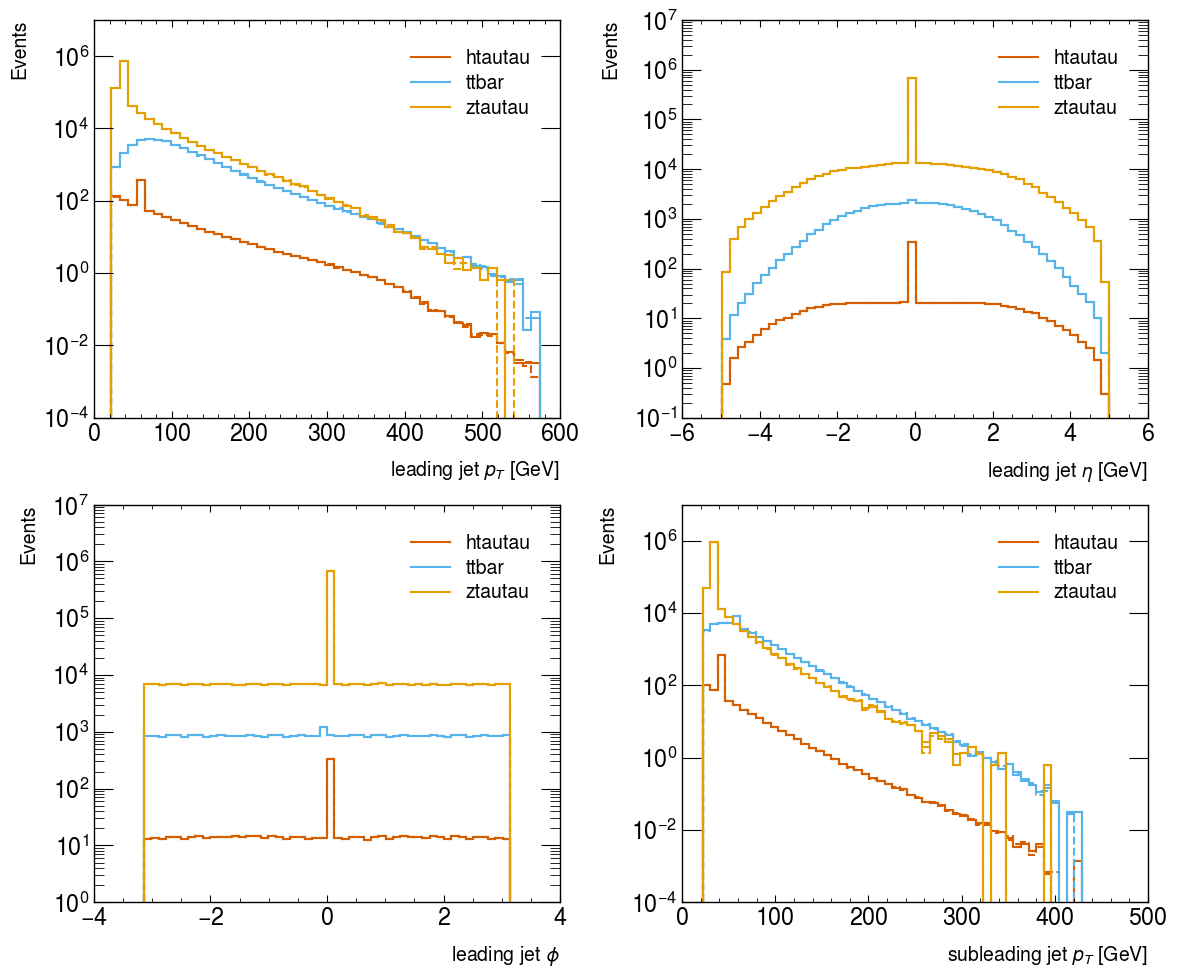

In [21]:
columns = ['PRI_jet_leading_pt', 'PRI_jet_leading_eta', 'PRI_jet_leading_phi', 'PRI_jet_subleading_pt']

# columns = ['PRI_had_pt', 'PRI_had_eta', 'PRI_had_phi']
nbins = 50

xlabel_dict = {
    'PRI_jet_leading_pt': 'leading jet $p_T$ [GeV]', 
    'PRI_jet_leading_eta': 'leading jet $\eta$ [GeV]', 
    'PRI_jet_leading_phi': 'leading jet $\phi$', 
    'PRI_jet_subleading_pt': 'subleading jet $p_T$ [GeV]',
}

variations_to_plot = ['Nominal', 'JES_Up', 'JES_Dn']


fig, axes = plot_kinematic_features(
    columns=columns,
    nbins=nbins,
    variations_to_plot=variations_to_plot,
    dataset_dict=datasets_all,
    xlabel_dict=xlabel_dict,
    samples_list=samples_list
)
plt.show()